# ⚙️ 보상 모델 (Reward Model) Loss 밑바닥부터 구현하기

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. Bradley-Terry 모델 기반 Loss Function
보상 모델은 텍스트를 입력받아 하나의 스칼라 값(점수)을 반환합니다. 우리가 훈련해야 할 목표는 **인간이 선택한 응답(Chosen)의 점수 $R_c$가 거절된 응답(Rejected)의 점수 $R_r$보다 커지도록** 만드는 것입니다.

In [2]:
def reward_loss(r_chosen, r_rejected):
    """
    r_chosen: 인간이 선택한 답변에 대해 보상 모델이 예측한 점수 (Tensor)
    r_rejected: 인간이 거절한 답변에 대해 보상 모델이 예측한 점수 (Tensor)
    """
    # 차이 계산: chosen이 rejected보다 얼마나 큰가?
    diff = r_chosen - r_rejected
    
    # Sigmoid 함수를 통과시켜 0~1 사이의 확률값으로 변환
    prob = torch.sigmoid(diff)
    
    # Negative Log Likelihood: 확률이 1에 가까울수록 Loss는 0에 가까워짐
    loss = -torch.log(prob).mean()
    return loss

# 테스트
R_c = torch.tensor([1.5])
R_r = torch.tensor([-0.5])
print(f"Chosen 점수가 높을 때의 Loss: {reward_loss(R_c, R_r).item():.4f} (정상: 낮아야 함)")

R_c = torch.tensor([-2.0])
R_r = torch.tensor([3.0])
print(f"Rejected 점수가 높을 때의 Loss: {reward_loss(R_c, R_r).item():.4f} (비정상: 높아야 함)")

Chosen 점수가 높을 때의 Loss: 0.1269 (정상: 낮아야 함)
Rejected 점수가 높을 때의 Loss: 5.0067 (비정상: 높아야 함)


## 2. 훈련 시뮬레이션
아무것도 모르는 초기 보상 모델이 데이터(선호도)를 반복 학습하면서 두 응답의 점수 격차를 벌려가는 과정을 시각화합니다.

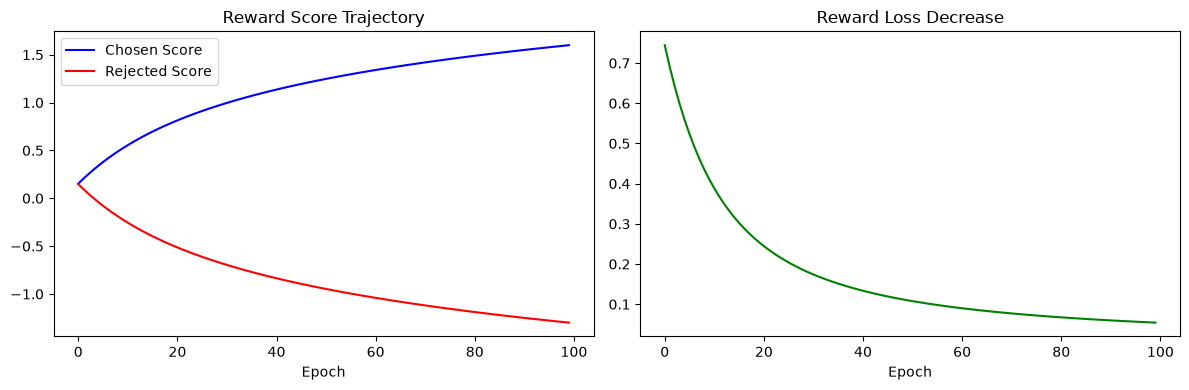

최종 Chosen 점수: 1.5990
최종 Rejected 점수: -1.2990
💡 결론: 모델이 학습을 진행할수록 인간이 좋아하는 답변에는 높은 가중치를, 싫어하는 답변에는 낮은 가중치를 부여하게 됩니다.


In [3]:
# 시뮬레이션을 위한 학습 파라미터 (가중치 역할)
# 초기에는 두 응답의 점수가 비슷하다고 가정 (둘 다 0 주변)
r_chosen_param = nn.Parameter(torch.tensor([0.1]))
r_rejected_param = nn.Parameter(torch.tensor([0.2]))

optimizer = torch.optim.SGD([r_chosen_param, r_rejected_param], lr=0.1)

history_c = []
history_r = []
loss_history = []

epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    
    loss = reward_loss(r_chosen_param, r_rejected_param)
    loss.backward()
    optimizer.step()
    
    history_c.append(r_chosen_param.item())
    history_r.append(r_rejected_param.item())
    loss_history.append(loss.item())

# 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_c, label='Chosen Score', color='blue')
plt.plot(history_r, label='Rejected Score', color='red')
plt.title("Reward Score Trajectory")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history, color='green')
plt.title("Reward Loss Decrease")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

print(f"최종 Chosen 점수: {history_c[-1]:.4f}")
print(f"최종 Rejected 점수: {history_r[-1]:.4f}")
print("💡 결론: 모델이 학습을 진행할수록 인간이 좋아하는 답변에는 높은 가중치를, 싫어하는 답변에는 낮은 가중치를 부여하게 됩니다.")